<a href="https://colab.research.google.com/github/srikavya26/Image-classification-challenge/blob/main/ViT_Base_Patch16_224.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import numpy as np
import urllib.request
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import os
from transformers import ViTForImageClassification, ViTImageProcessor
import torch.nn.functional as F
import seaborn as sns

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.7'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
# Check Albumentations version
print(f"Albumentations version: {A.__version__}")

Albumentations version: 2.0.7


In [ ]:
# Download CIFAR-10.1 v6 dataset
data_url = "https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_data.npy"
label_url = "https://github.com/modestyachts/CIFAR-10.1/raw/master/datasets/cifar10.1_v6_labels.npy"
urllib.request.urlretrieve(data_url, "cifar10.1_v6_data.npy")
urllib.request.urlretrieve(label_url, "cifar10.1_v6_labels.npy")

# Load data
data = np.load("cifar10.1_v6_data.npy")  # shape: (2000, 32, 32, 3)
labels = np.load("cifar10.1_v6_labels.npy")  # shape: (2000,)
print(f"Data min: {data.min()}, Data max: {data.max()}")

# Step 1: Dataset Structure
print("\n=== Dataset Structure ===")
print(f"Data Shape: {data.shape}, Dtype: {data.dtype}")
print(f"Labels Shape: {labels.shape}, Dtype: {labels.dtype}")
print(f"Number of Samples: {data.shape[0]}")
print(f"Image Dimensions: {data.shape[1]}x{data.shape[2]} pixels, {data.shape[3]} channels (RGB)")
print(f"Label Range: {labels.min()} to {labels.max()}")

# Step 2: Class Distribution
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_counts = np.bincount(labels)
print("\n=== Class Distribution ===")
for i, count in enumerate(class_counts):
    print(f"{class_names[i]} (Class {i}): {count} samples ({count/len(labels)*100:.1f}%)")


Data min: 0, Data max: 255

=== Dataset Structure ===
Data Shape: (2000, 32, 32, 3), Dtype: uint8
Labels Shape: (2000,), Dtype: int32
Number of Samples: 2000
Image Dimensions: 32x32 pixels, 3 channels (RGB)
Label Range: 0 to 9

=== Class Distribution ===
airplane (Class 0): 200 samples (10.0%)
automobile (Class 1): 200 samples (10.0%)
bird (Class 2): 200 samples (10.0%)
cat (Class 3): 200 samples (10.0%)
deer (Class 4): 200 samples (10.0%)
dog (Class 5): 200 samples (10.0%)
frog (Class 6): 200 samples (10.0%)
horse (Class 7): 200 samples (10.0%)
ship (Class 8): 200 samples (10.0%)
truck (Class 9): 200 samples (10.0%)


In [ ]:
# Step 3: Characteristics
print("\n=== Dataset Characteristics ===")
print("Dataset: CIFAR-10.1 v6, a new test set for CIFAR-10 with 2000 images.")
print("Image Properties: 32x32 pixels, RGB, low-resolution, centered objects.")
print("Classes: 10, balanced, covering vehicles (airplane, automobile, ship, truck) and animals (bird, cat, deer, dog, frog, horse).")
print("Challenges: Low resolution, visual similarity (e.g., cat/dog, airplane/ship), diverse lighting/backgrounds.")


=== Dataset Characteristics ===
Dataset: CIFAR-10.1 v6, a new test set for CIFAR-10 with 2000 images.
Image Properties: 32x32 pixels, RGB, low-resolution, centered objects.
Classes: 10, balanced, covering vehicles (airplane, automobile, ship, truck) and animals (bird, cat, deer, dog, frog, horse).
Challenges: Low resolution, visual similarity (e.g., cat/dog, airplane/ship), diverse lighting/backgrounds.


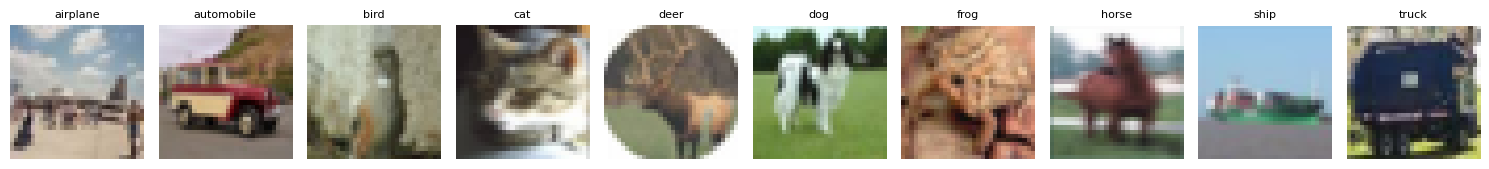

In [ ]:
# Step 4: Visualizations

# Visualization 1: Sample Images (1 per class, randomized)
plt.figure(figsize=(15, 2))
for i in range(10):
    # Get all indices for the current class
    class_indices = np.where(labels == i)[0]
    # Randomly select one index from the class indices
    idx = np.random.choice(class_indices)
    plt.subplot(1, 10, i+1)
    plt.imshow(data[idx].astype(np.uint8))
    plt.title(class_names[i], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


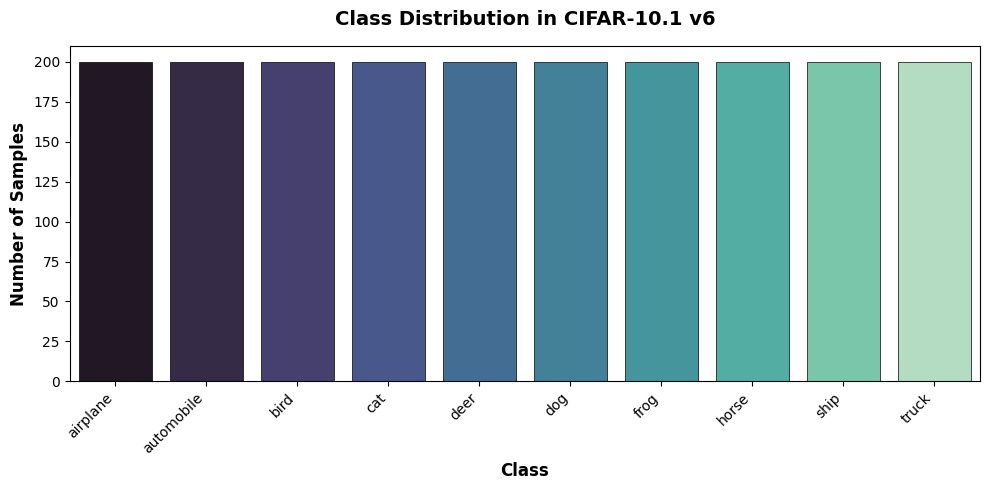

In [ ]:
# Visualization 2: Class Distribution Bar Chart

plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=class_counts, hue=class_names, palette='mako', edgecolor='black', linewidth=0.5, legend=False)
plt.xlabel('Class', fontsize=12, weight='bold')
plt.ylabel('Number of Samples', fontsize=12, weight='bold')
plt.title('Class Distribution in CIFAR-10.1 v6', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution_mako.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# Define Albumentations transforms (adjusted for ViT input size 224x224)
train_transform = A.Compose([
    A.Resize(224, 224, interpolation=1),  # Resize to 224x224 for ViT
    A.HorizontalFlip(p=0.5),
    A.PadIfNeeded(min_height=228, min_width=228, p=1.0),
    A.RandomCrop(height=224, width=224, p=1.0),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.CoarseDropout(
        num_holes_range=(1, 1),
        hole_height_range=(8, 8),
        hole_width_range=(8, 8),
        fill=0,
        fill_mask=None,
        p=0.5
    ),
    A.Affine(translate_percent=0.1, scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Resize(224, 224, interpolation=1),  # Resize to 224x224 for ViT
    A.CenterCrop(height=224, width=224, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
# Function to visualize original and augmented images
def visualize_augmentations(data, labels, class_names, transform, class_labels=None, num_images=10):

    # Filter by class_labels if specified
    if class_labels is not None:
        if isinstance(class_labels, int):
            class_labels = [class_labels]
        mask = np.isin(labels, class_labels)
        selected_data = data[mask]
        selected_labels = labels[mask]
        if len(selected_data) == 0:
            print(f"No images found for class labels: {class_labels}")
            return
    else:
        selected_data = data
        selected_labels = labels

    # Randomly select up to num_images
    indices = np.random.choice(len(selected_data), min(num_images, len(selected_data)), replace=False)
    selected_images = selected_data[indices]
    selected_labels = selected_labels[indices]

    # Set up plot
    plt.figure(figsize=(4 * len(indices), 4))

    for i, (img, label) in enumerate(zip(selected_images, selected_labels)):
        # Original image
        plt.subplot(2, len(indices), i + 1)
        plt.imshow(img.astype(np.uint8))
        plt.title(f"{class_names[label]} (Original)", fontsize=10)
        plt.axis('off')

        # Augmented image
        aug_img = transform(image=img.astype(np.uint8))['image']
        aug_img = aug_img.permute(1, 2, 0).numpy()  # (C, H, W) to (H, W, C)
        aug_img = aug_img * np.array([0.247, 0.243, 0.261]) + np.array([0.4914, 0.4822, 0.4465])
        aug_img = np.clip(aug_img, 0, 1)
        plt.subplot(2, len(indices), i + 1 + len(indices))
        plt.imshow(aug_img)
        plt.title(f"{class_names[label]} (Augmented)", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


=== Visualizing Augmentations for All Classes ===


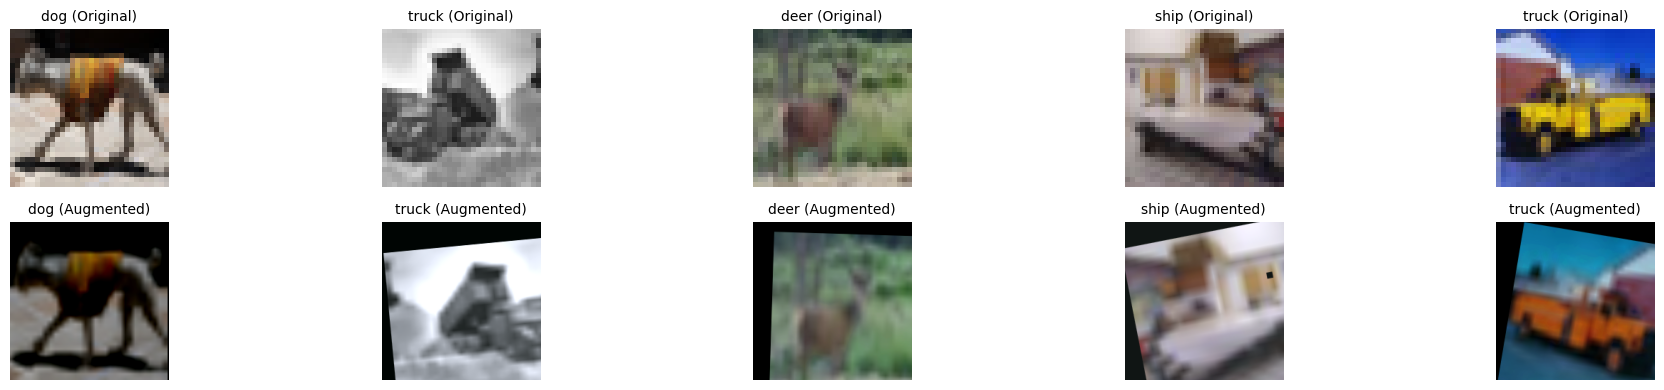


=== Visualizing Augmentations for Class 0 (Airplane) ===


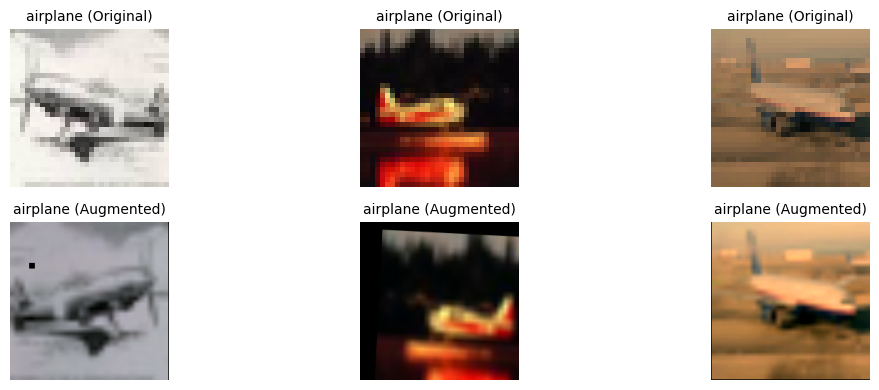


=== Visualizing Augmentations for Classes 0 (Airplane) and 3 (Cat) ===


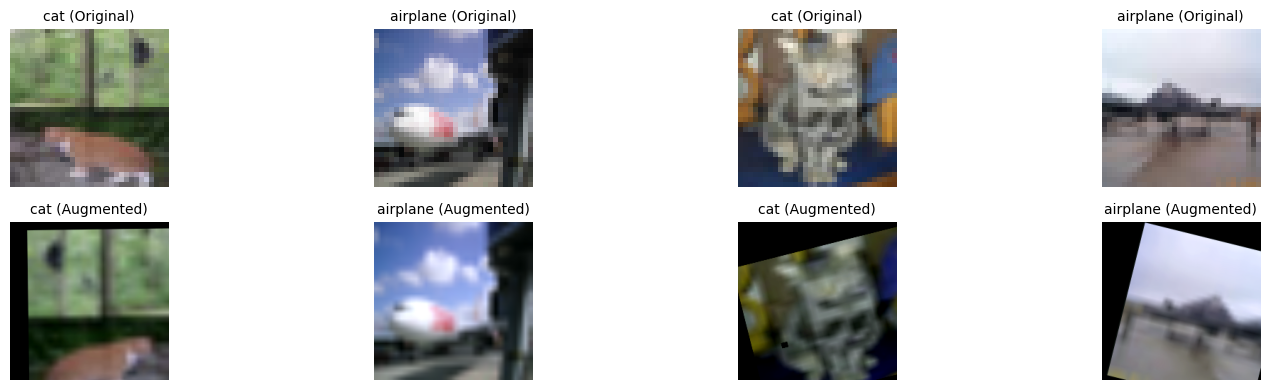

In [ ]:
# Example visualizations
print("\n=== Visualizing Augmentations for All Classes ===")
visualize_augmentations(data, labels, class_names, train_transform, class_labels=None, num_images=5)

print("\n=== Visualizing Augmentations for Class 0 (Airplane) ===")
visualize_augmentations(data, labels, class_names, train_transform, class_labels=0, num_images=3)

print("\n=== Visualizing Augmentations for Classes 0 (Airplane) and 3 (Cat) ===")
visualize_augmentations(data, labels, class_names, train_transform, class_labels=[0, 3], num_images=4)

In [ ]:
# Custom dataset
class CIFAR10_1_Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images  # Shape: (N, 32, 32, 3)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].numpy().astype(np.uint8)
        label = self.labels[idx]
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
        return img, label

In [ ]:
# Define MixUp function
def mixup_data(x, y, alpha=0.2, device='cuda'):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Define MixUp loss function
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:
# Define Test-Time Augmentation (TTA) function
def apply_tta(model, images, device):
    model.eval()
    with torch.no_grad():
        outputs = model(images).logits
        flipped_images = TF.hflip(images)
        flipped_outputs = model(flipped_images).logits
        outputs = (outputs + flipped_outputs) / 2
    return outputs

In [ ]:
# Load pretrained ViT model and feature extractor
model_name = "nielsr/vit-base-patch16-224-in21k-finetuned-cifar10"
model = ViTForImageClassification.from_pretrained(model_name)
feature_extractor = ViTImageProcessor.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

# Freeze early layers (e.g., first 6 transformer blocks)
for name, param in model.named_parameters():
    if "vit.encoder.layer" in name and int(name.split('.')[3]) < 6:
        param.requires_grad = False

# Define loss function
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

Using device: cuda


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]


=== Training Fold 1/5 ===
Fold 1 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 1, Epoch 1, Batch 50/50, Batch Loss: 1.7346
Fold 1, Epoch 1, Average Loss: 2.0851, Training Accuracy: 0.2162
Fold 1, Epoch 1, Validation Loss: 1.6949, Validation Accuracy (TTA): 0.6675
Fold 1, Epoch 2, Batch 50/50, Batch Loss: 1.3009
Fold 1, Epoch 2, Average Loss: 1.4750, Training Accuracy: 0.4006
Fold 1, Epoch 2, Validation Loss: 1.1415, Validation Accuracy (TTA): 0.8475
Fold 1, Epoch 3, Batch 50/50, Batch Loss: 1.0357
Fold 1, Epoch 3, Average Loss: 1.1486, Training Accuracy: 0.4813
Fold 1, Epoch 3, Validation Loss: 0.8990, Validation Accuracy (TTA): 0.8950
Fold 1, Epoch 4, Batch 50/50, Batch Loss: 0.6607
Fold 1, Epoch 4, Avera

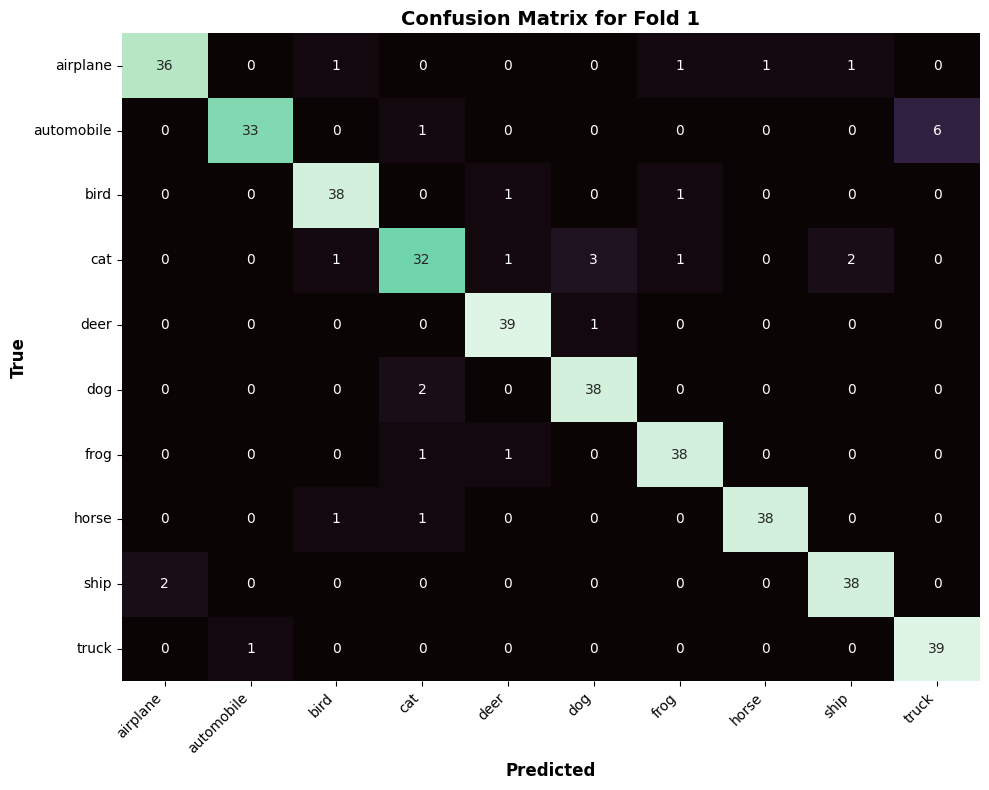


=== Training Fold 2/5 ===
Fold 2 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 2, Epoch 1, Batch 50/50, Batch Loss: 0.6463
Fold 2, Epoch 1, Average Loss: 0.7592, Training Accuracy: 0.5650
Fold 2, Epoch 1, Validation Loss: 0.5388, Validation Accuracy (TTA): 0.9900
Fold 2, Epoch 2, Batch 50/50, Batch Loss: 0.5512
Fold 2, Epoch 2, Average Loss: 0.6752, Training Accuracy: 0.4944
Fold 2, Epoch 2, Validation Loss: 0.5332, Validation Accuracy (TTA): 0.9900
Fold 2, Epoch 3, Batch 50/50, Batch Loss: 0.5726
Fold 2, Epoch 3, Average Loss: 0.6869, Training Accuracy: 0.6488
Fold 2, Epoch 3, Validation Loss: 0.5248, Validation Accuracy (TTA): 0.9950
Fold 2, Epoch 4, Batch 50/50, Batch Loss: 0.6539
Fold 2, Epoch 4, Avera

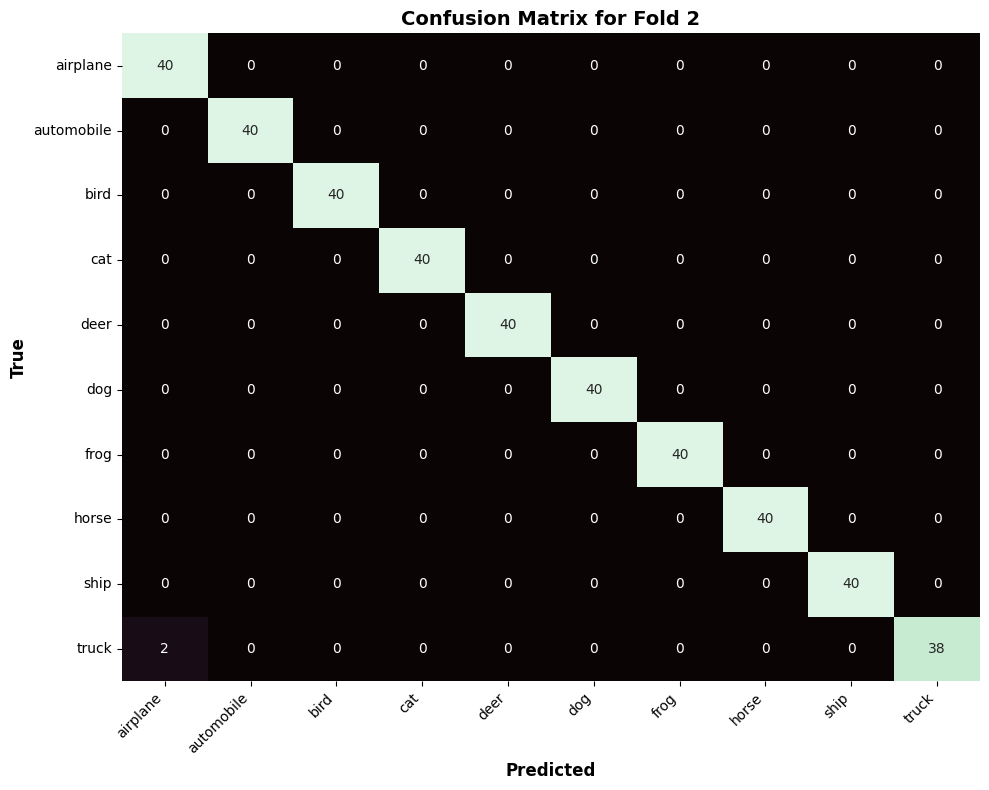


=== Training Fold 3/5 ===
Fold 3 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 3, Epoch 1, Batch 50/50, Batch Loss: 0.5367
Fold 3, Epoch 1, Average Loss: 0.7929, Training Accuracy: 0.5350
Fold 3, Epoch 1, Validation Loss: 0.5175, Validation Accuracy (TTA): 1.0000
Fold 3, Epoch 2, Batch 50/50, Batch Loss: 1.8199
Fold 3, Epoch 2, Average Loss: 0.7964, Training Accuracy: 0.5256
Fold 3, Epoch 2, Validation Loss: 0.5185, Validation Accuracy (TTA): 1.0000
Fold 3, Epoch 3, Batch 50/50, Batch Loss: 0.5281
Fold 3, Epoch 3, Average Loss: 0.6152, Training Accuracy: 0.4963
Fold 3, Epoch 3, Validation Loss: 0.5194, Validation Accuracy (TTA): 0.9975
Fold 3, Epoch 4, Batch 50/50, Batch Loss: 0.5074
Fold 3, Epoch 4, Avera

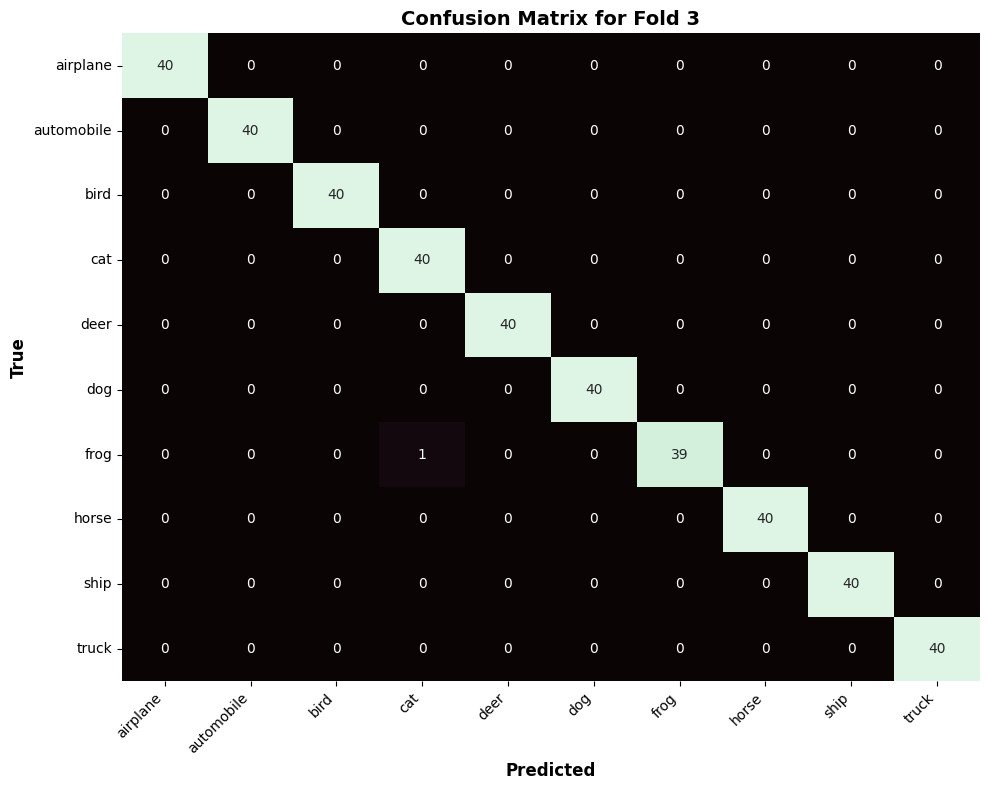


=== Training Fold 4/5 ===
Fold 4 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 4, Epoch 1, Batch 50/50, Batch Loss: 0.5241
Fold 4, Epoch 1, Average Loss: 0.7289, Training Accuracy: 0.5994
Fold 4, Epoch 1, Validation Loss: 0.5071, Validation Accuracy (TTA): 1.0000
Fold 4, Epoch 2, Batch 50/50, Batch Loss: 0.5509
Fold 4, Epoch 2, Average Loss: 0.6413, Training Accuracy: 0.6075
Fold 4, Epoch 2, Validation Loss: 0.5041, Validation Accuracy (TTA): 1.0000
Fold 4, Epoch 3, Batch 50/50, Batch Loss: 0.5556
Fold 4, Epoch 3, Average Loss: 0.7450, Training Accuracy: 0.5162
Fold 4, Epoch 3, Validation Loss: 0.5092, Validation Accuracy (TTA): 1.0000
Fold 4, Epoch 4, Batch 50/50, Batch Loss: 0.5084
Fold 4, Epoch 4, Avera

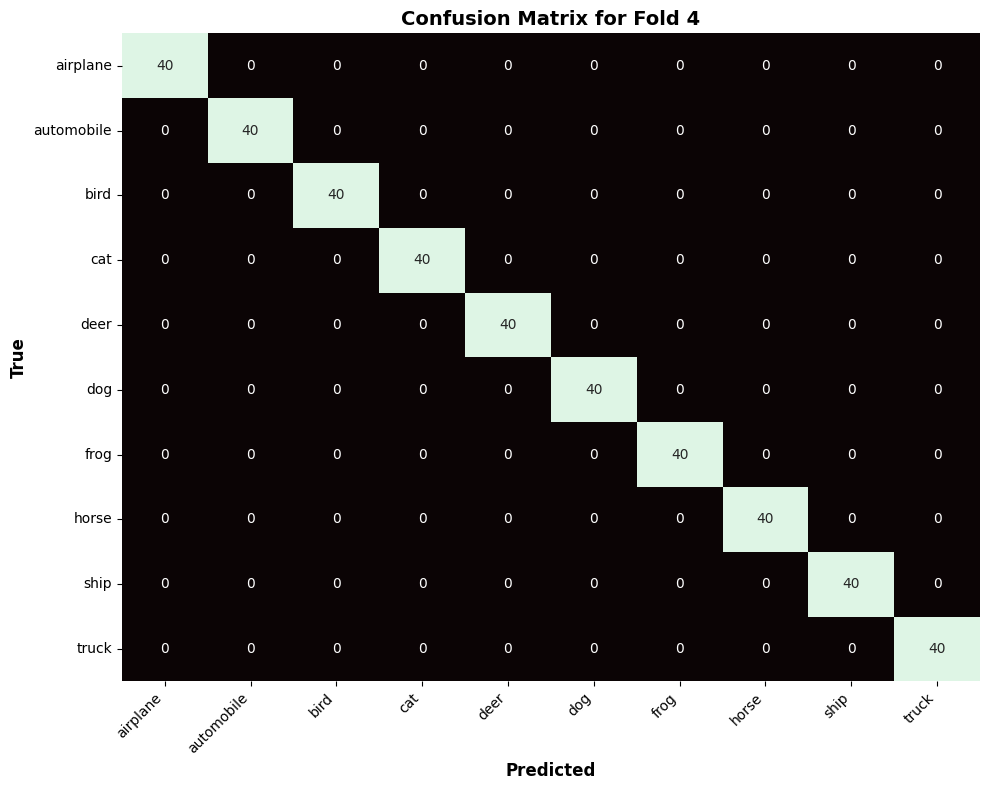


=== Training Fold 5/5 ===
Fold 5 test class distribution:
  airplane (Class 0): 40 samples
  automobile (Class 1): 40 samples
  bird (Class 2): 40 samples
  cat (Class 3): 40 samples
  deer (Class 4): 40 samples
  dog (Class 5): 40 samples
  frog (Class 6): 40 samples
  horse (Class 7): 40 samples
  ship (Class 8): 40 samples
  truck (Class 9): 40 samples
Fold 5, Epoch 1, Batch 50/50, Batch Loss: 0.5058
Fold 5, Epoch 1, Average Loss: 0.6841, Training Accuracy: 0.4219
Fold 5, Epoch 1, Validation Loss: 0.5072, Validation Accuracy (TTA): 0.9975
Fold 5, Epoch 2, Batch 50/50, Batch Loss: 0.5120
Fold 5, Epoch 2, Average Loss: 0.6814, Training Accuracy: 0.4950
Fold 5, Epoch 2, Validation Loss: 0.5184, Validation Accuracy (TTA): 0.9950
Fold 5, Epoch 3, Batch 50/50, Batch Loss: 0.6069
Fold 5, Epoch 3, Average Loss: 0.6587, Training Accuracy: 0.5413
Fold 5, Epoch 3, Validation Loss: 0.5188, Validation Accuracy (TTA): 0.9975
Fold 5, Epoch 4, Batch 50/50, Batch Loss: 1.5786
Fold 5, Epoch 4, Avera

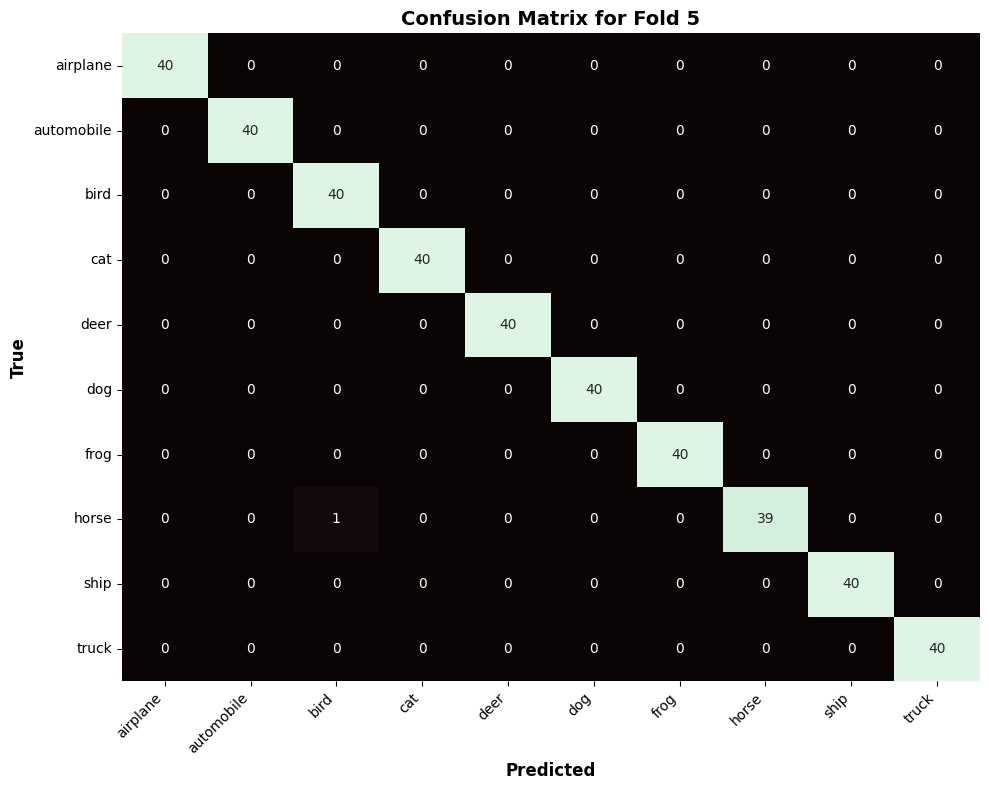


=== Final Results (5-Fold CV) ===
Average Accuracy: 0.9825 ± 0.0300
Average F1-Score: 0.9824 ± 0.0303


In [ ]:
# Define stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=789)
folds = list(skf.split(data, labels))

# Store results
accuracies = []
f1_scores = []
confusion_matrices = []  # Store confusion matrices for each fold


for fold, (train_idx, test_idx) in enumerate(folds):
    print(f"\n=== Training Fold {fold+1}/5 ===")

    # Analyze class distribution for every fold
    print(f"Fold {fold+1} test class distribution:")
    class_counts = np.bincount(labels[test_idx])
    for i, count in enumerate(class_counts):
        print(f"  {class_names[i]} (Class {i}): {count} samples")

    # Create datasets
    train_dataset = CIFAR10_1_Dataset(
        torch.tensor(data[train_idx], dtype=torch.float32),
        torch.tensor(labels[train_idx], dtype=torch.long),
        transform=train_transform
    )
    test_dataset = CIFAR10_1_Dataset(
        torch.tensor(data[test_idx], dtype=torch.float32),
        torch.tensor(labels[test_idx], dtype=torch.long),
        transform=test_transform
    )

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    # Optimizer
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=4e-5, weight_decay=5e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

    # Training loop
    best_val_loss = float('inf')
    patience = 7
    counter = 0
    model.train()
    for epoch in range(20):
        running_loss = 0.0
        correct = 0
        total = 0
        # Unfreeze more layers at epoch 6
        if epoch == 6:
            for name, param in model.named_parameters():
                if "vit.encoder.layer" in name and int(name.split('.')[3]) in [6, 7]:
                    param.requires_grad = True
            optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=5e-2)

        for i, (images, targets) in enumerate(train_loader):
            images, targets = images.to(device), targets.to(device)

            # Apply MixUp with 50% probability
            if np.random.rand() < 0.5:
                images, targets_a, targets_b, lam = mixup_data(images, targets, alpha=0.2, device=device)
                optimizer.zero_grad()
                outputs = model(images).logits
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                optimizer.zero_grad()
                outputs = model(images).logits
                loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            if np.random.rand() < 0.5:  # For MixUp, use primary target for accuracy
                correct += (preds == targets_a).sum().item()
            else:
                correct += (preds == targets).sum().item()
            total += targets.size(0)

            if (i + 1) % 50 == 0:
                print(f"Fold {fold+1}, Epoch {epoch+1}, Batch {i+1}/{len(train_loader)}, "
                      f"Batch Loss: {loss.item():.4f}")

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total
        print(f"Fold {fold+1}, Epoch {epoch+1}, Average Loss: {epoch_loss:.4f}, "
              f"Training Accuracy: {epoch_acc:.4f}")

        # Validation with TTA
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for images, targets in test_loader:
                images, targets = images.to(device), targets.to(device)
                outputs = model(images).logits
                val_loss += criterion(outputs, targets).item()
                outputs = apply_tta(model, images, device)
                _, tta_preds = torch.max(outputs, 1)
                val_correct += (tta_preds == targets).sum().item()
                val_total += targets.size(0)
                all_preds.extend(tta_preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
        val_loss /= len(test_loader)
        val_acc = val_correct / val_total
        print(f"Fold {fold+1}, Epoch {epoch+1}, Validation Loss: {val_loss:.4f}, "
              f"Validation Accuracy (TTA): {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f'vit_fold_{fold+1}.pth')
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at Epoch {epoch+1}")
                break
        model.train()
        scheduler.step()

    # Final evaluation
    model.load_state_dict(torch.load(f'vit_fold_{fold+1}.pth'))
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = apply_tta(model, images, device)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')
    accuracies.append(acc)
    f1_scores.append(f1)

    # Compute and store confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    confusion_matrices.append(cm)

    print(f"Fold {fold+1} - Final Validation Accuracy (TTA): {acc:.4f}, Validation F1-Score: {f1:.4f}")
    print(f"Fold {fold+1} Classification Report:")
    print(classification_report(all_targets, all_preds, digits=4))


    # Plot and save per-fold confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted', fontsize=12, weight='bold')
    plt.ylabel('True', fontsize=12, weight='bold')
    plt.title(f'Confusion Matrix for Fold {fold+1}', fontsize=14, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_fold_{fold+1}.png')
    plt.show()
    plt.close()

# Report final results
print(f"\n=== Final Results (5-Fold CV) ===")
print(f"Average Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")



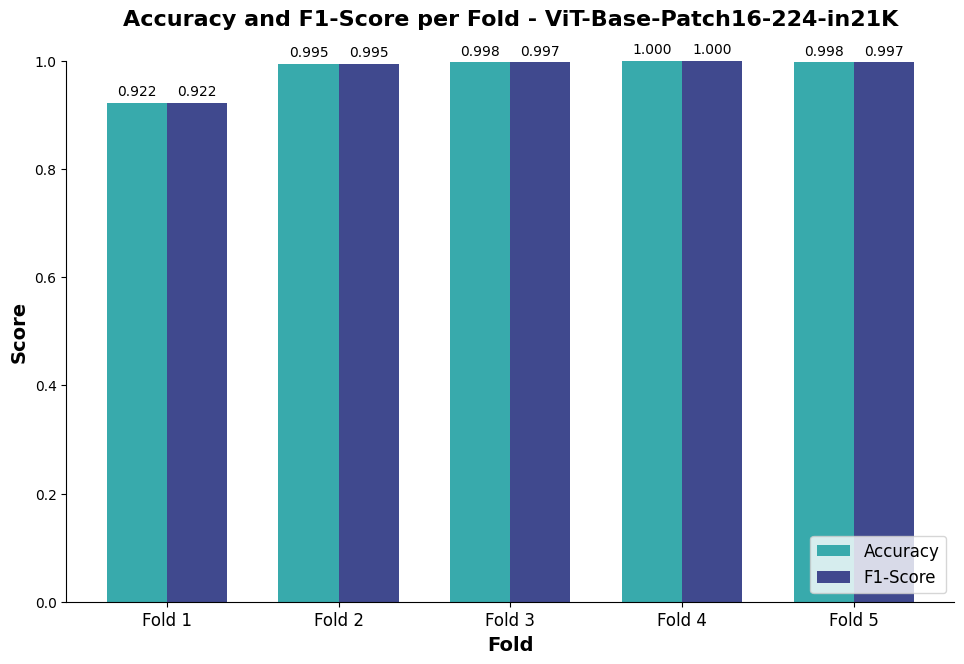

In [ ]:
# Create figure with increased height
plt.figure(figsize=(10, 7))

# Define data
x = np.arange(5)
width = 0.35

# Plot bars with muted palette
palette = sns.color_palette("mako", 2)
bar1 = plt.bar(x - width/2, accuracies, width, label='Accuracy', color=palette[1])
bar2 = plt.bar(x + width/2, f1_scores, width, label='F1-Score', color=palette[0])

# Add value labels on bars
for bar in [bar1, bar2]:
    plt.bar_label(bar, fmt='%.3f', fontsize=10, padding=3, color='black')

# Customize plot
plt.xlabel('Fold', fontsize=14, weight='bold')
plt.ylabel('Score', fontsize=14, weight='bold')
plt.title('Accuracy and F1-Score per Fold - ViT-Base-Patch16-224-in21K', fontsize=16, weight='bold', y=1.05)
plt.xticks(x, [f'Fold {i+1}' for i in range(5)], fontsize=12)
plt.ylim(0, 1)
plt.legend(fontsize=12, loc='lower right')

# Adjust layout with padding and remove top/right spines
plt.tight_layout(pad=2)
sns.despine()

# Save and display
plt.savefig('fold_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()